# Практическое задание №5

Используйте данные из файла **burnout.xlsx** с информацией об академических работниках.

В нём содержаться следующие переменные:


| Название переменной | Описание переменной
|:-------------------:|:------------------:|
| burnout | выгорание на работе |
| loc | ощущаемый контроль (чем больше значение, тем меньше ощущение контроля над ситуацией) |
| cope | способность справляться со сложностями (чем больше значение, тем меньше способность)|
| teaching | стресс от преподавания (чем выше значение, тем выше уровень стресса)|
| research | стресс от проведения исследований (чем выше значение, тем выше уровень стресса)|
| pastoral | стресс от бескорыстной помощи коллегам и студентам (чем выше значение, тем выше уровень стресса)|
| gender |	пол (мужской, женский)|
| degree |	наличие ученой степени (phd – кандидат наук, mba - мастер делового администрирования, ms – магистр)|


Метрические переменные измерены по шкале от 0 до 100.

Выполните, пожалуйста, следующие задания.

##Задание 1

1. Сформулируйте гипотезы, которые будут проверены в ходе исследования.

In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

In [70]:
url = '/content/burnout.xlsx'

In [71]:
df = pd.read_excel(url)

In [72]:
df

,burnout,loc,cope,teaching,research,pastoral,gender,degree
0,Burnt Out,61.764706,81.679389,94.545455,81.250000,96.296296,male,mba
1,Burnt Out,42.941176,39.694656,94.545455,60.416667,87.037037,male,mba
2,Burnt Out,22.352941,17.557252,63.636364,64.583333,68.518519,male,mba
3,Burnt Out,13.529412,25.190840,60.000000,62.500000,66.666667,male,mba
4,Burnt Out,38.235294,34.351145,61.818182,68.750000,61.111111,male,mba
...,...,...,...,...,...,...,...,...
462,Not Burnt Out,7.647059,17.557252,45.454545,47.916667,33.333333,female,phd
463,Not Burnt Out,6.470588,10.687023,27.272727,56.250000,31.481481,female,phd
464,Not Burnt Out,55.882353,24.427481,69.090909,64.583333,29.629630,female,phd
465,Not Burnt Out,7.647059,13.740458,34.545455,79.166667,24.074074,female,phd


In [73]:
df.shape

(467, 8)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 467 entries, 0 to 466
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   burnout   467 non-null    object 
 1   loc       467 non-null    float64
 2   cope      467 non-null    float64
 3   teaching  467 non-null    float64
 4   research  467 non-null    float64
 5   pastoral  467 non-null    float64
 6   gender    467 non-null    object 
 7   degree    467 non-null    object 
dtypes: float64(5), object(3)
memory usage: 29.3+ KB


Датасет состоит из 467 наблюдений, включает 8 переменных. Не содержит пропущенных значений.

In [75]:
for t in df.dtypes.unique():
     print('Type: {}\n{}\n'.format(t, df.dtypes[df.dtypes==t].index.values))

Type: object
['burnout' 'gender' 'degree']

Type: float64
['loc' 'cope' 'teaching' 'research' 'pastoral']



Гипотезы:

1. Между полом и выгоранием на работе нет взаимосвязи.

2. Выгорание может наступить у работника вне зависимости от его ученой степени.

3. С ростом ощущения своего контроля над ситуацией снижается вероятность выгорания на работе (то есть предполагается прямая взаимосвязь между loc и burnout).

4. Чем выше способность справлять со сложностями, тем ниже шансы выгореть на работе (прямая взаимосвязь между cope и burnout).

5. Есть прямая взаимосвязь между испытываемым стрессом от преподавания (teaching) и фактом выгорания.

6. Есть прямая взаимосвязь между стрессом от проведения исследований (research) и выгоранием.

7. Выгорание напрямую связана со стрессом от бескорыстной помощи коллегам и студентам (pastoral).

##Задание 2

2. Постройте модель бинарной логистической регрессии. Зависимая переменная – burnout. В качестве предикторов используйте все остальные переменные. Напишите уравнение регрессии (линейная часть). Охарактеризуйте регрессионную модель. Оцените статическую значимость и предсказательную силу модели. Постройте ROC-кривую и прокомментируйте ее. Рассчитайте площадь под ROC-кривой.

###Зависимая переменная

Переменная burnout - бинарная.

In [76]:
df['burnout'].value_counts()

,count
burnout,
Not Burnt Out,348
Burnt Out,119


In [77]:
df['burnout2'] = df['burnout'].replace({'Not Burnt Out': 0, 'Burnt Out': 1})
#чтобы включить переменную в модель, перекодируем и включим ее как новую переменную в датасет

In [78]:
df['burnout2'].dtype

dtype('int64')

###Предикторы

В модель будут включены 7 предикторов. Переменные loc, cope, teaching, research, pastoral имеют тип float. Для включения в модель переменных gender и degree типа object, создадим dummy переменные.

In [79]:
df['gender'].value_counts()
#в качестве референтной возьмем группу female

,count
gender,
female,234
male,233


In [80]:
gender_dummies=pd.get_dummies(df.gender, prefix='gender', prefix_sep='_', dtype=int)
gender_dummies.head()

,gender_female,gender_male
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


In [81]:
df['degree'].value_counts()
#в качестве референтной возьмем группу phd

,count
degree,
phd,310
ms,85
mba,72


In [82]:
degree_dummies=pd.get_dummies(df.degree, prefix='degree', prefix_sep='_', dtype=int)
degree_dummies.head()

,degree_mba,degree_ms,degree_phd
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0


In [83]:
df2 = pd.concat([df, degree_dummies, gender_dummies], axis=1)
df2

,burnout,loc,cope,teaching,research,pastoral,gender,degree,burnout2,degree_mba,degree_ms,degree_phd,gender_female,gender_male
0,Burnt Out,61.764706,81.679389,94.545455,81.250000,96.296296,male,mba,1,1,0,0,0,1
1,Burnt Out,42.941176,39.694656,94.545455,60.416667,87.037037,male,mba,1,1,0,0,0,1
2,Burnt Out,22.352941,17.557252,63.636364,64.583333,68.518519,male,mba,1,1,0,0,0,1
3,Burnt Out,13.529412,25.190840,60.000000,62.500000,66.666667,male,mba,1,1,0,0,0,1
4,Burnt Out,38.235294,34.351145,61.818182,68.750000,61.111111,male,mba,1,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
462,Not Burnt Out,7.647059,17.557252,45.454545,47.916667,33.333333,female,phd,0,0,0,1,1,0
463,Not Burnt Out,6.470588,10.687023,27.272727,56.250000,31.481481,female,phd,0,0,0,1,1,0
464,Not Burnt Out,55.882353,24.427481,69.090909,64.583333,29.629630,female,phd,0,0,0,1,1,0
465,Not Burnt Out,7.647059,13.740458,34.545455,79.166667,24.074074,female,phd,0,0,0,1,1,0


###Предварительный анализ взаимосвязей между предикторами и зависимой переменной

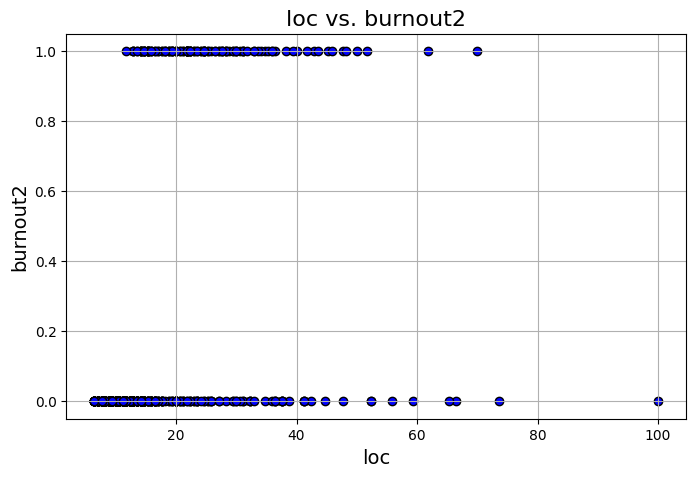

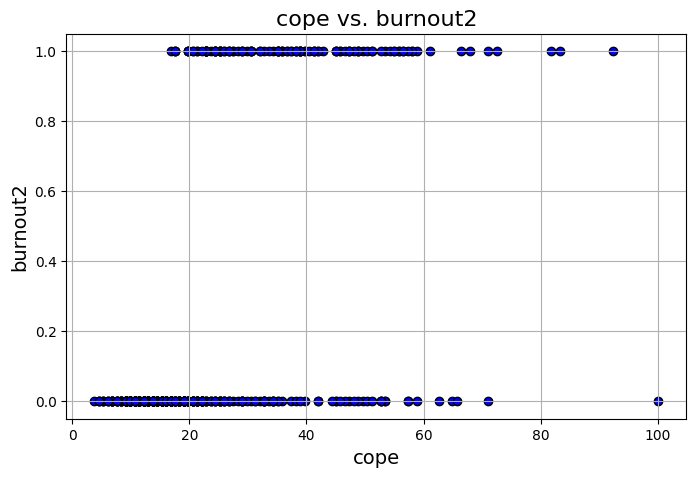

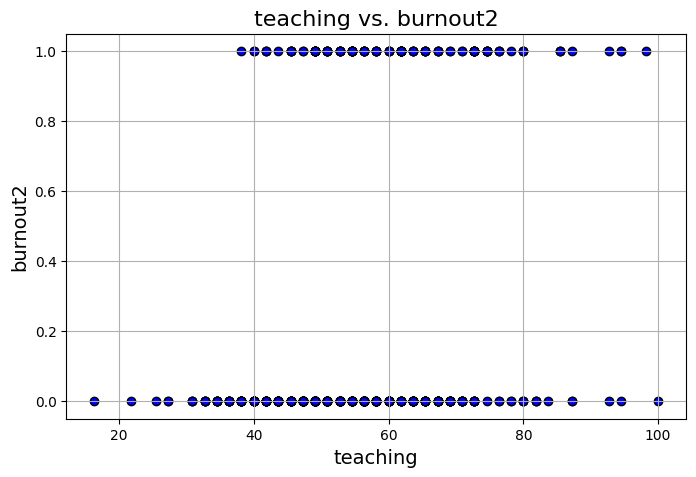

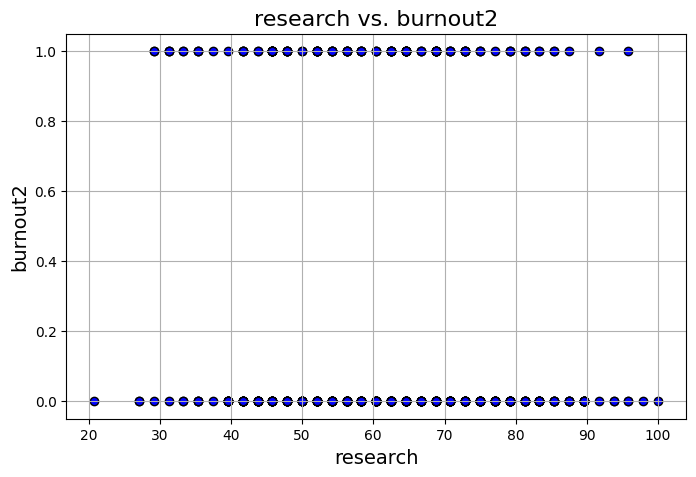

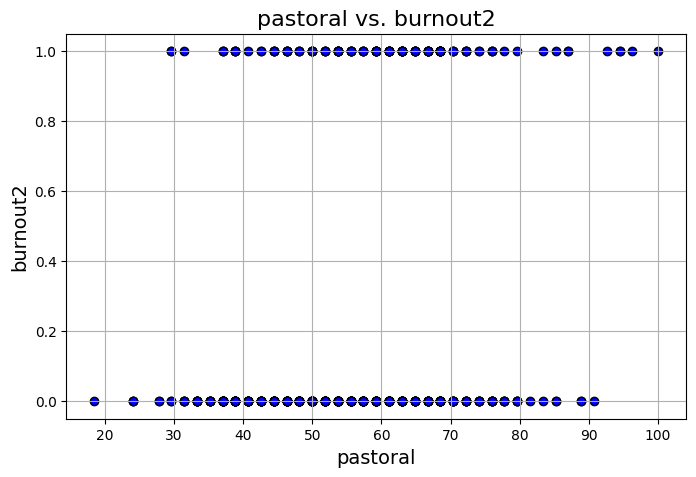

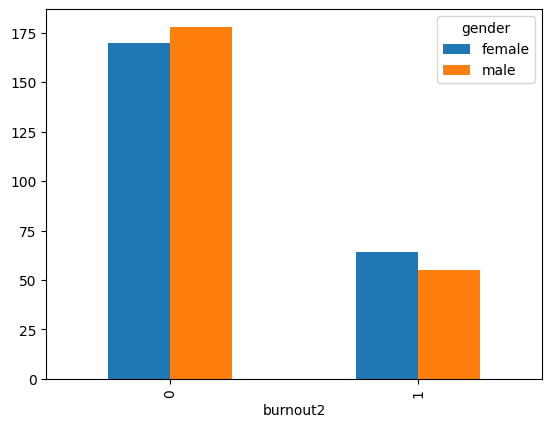

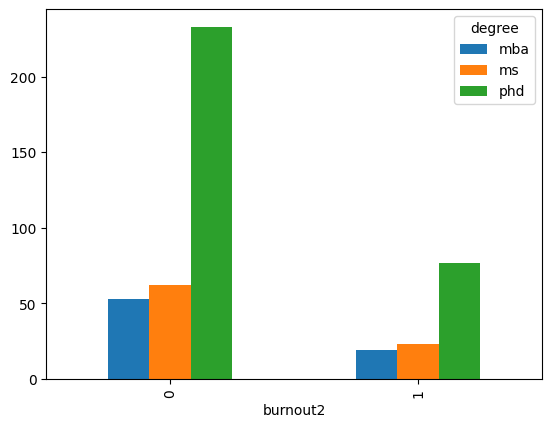

In [84]:
for c in df.columns[1:]:
    if c == 'loc' or c == 'cope' or c=='teaching' or c=='research' or c=='pastoral':
        plt.figure(figsize=(8,5))
        plt.title('{} vs. burnout2'.format(c), fontsize=16)
        plt.scatter(x=df[c], y=df.burnout2, color='blue',edgecolor='k')
        plt.grid(True)
        plt.xlabel(c, fontsize=14)
        plt.ylabel('burnout2', fontsize=14)
        plt.show()
    elif c == 'gender' or c == 'degree':
        ct = pd.crosstab(df.burnout2, df[c])
        ct.plot.bar()

Выводы:

Построенные диаграммы позволяют сделать вывод о том, представлены ли все сочетания данных, есть ли в них разнообразие и насколько целесообразно брать тот или иной предиктор в модель.

Предиктор loc: есть разнообразие как в группе столкнувшихся с выгоранием на работе и к нему не склонных. Нельзя сделать однозначный вывод только с помощью данного предиктора, что, к примеру, не выгорели на работе только те, которые отмечают свой высокий контроль над ситуацией (с низким значением показателя). Тем не менее можно отметить, что данные в обеих группах скопились больше в области с низкими значениями показателя (до 50), с высоким ощущением контроля над ситуацией. Есть риск, что предиктор может быть не значим.

Предиктор cope: есть разнообразие в данных. Предиктор нельзя отнести к идеальному классификатору, так как нельзя только на основе способности справляться со сложностями сказать, столкнулся ли работник с проблемой выгорания. Значит, предиктор можно взять в модель. Также можно отметить тенденцию, что люди с сильно развитой способностью справляться со сложностями меньше склонны к выгоранию. Можно предварительно отметить наличие взаимосвязи между предиктором и зависимой переменной.

Есть разброс значений предикторов teaching, research, pastoral в обеих группах. Можно взять данные предикторы в модель. При этом можно отметить, что работники с высоким уровнем стресса от преподавания (teaching) больше сталкиваются с выгоранием. Также у людей с высоким стрессом от бескорыстной помощи (pastoral) чаще происходит выгорание. При этом может не быть зависимости между выгоранием и стрессом от исследовательской деятельности, так как в случае даже самых высоких значений показателя (выше 90), у большинства работников не случалось выгорания. В группе людей, испытывающих эту проблему, значения стресса от проведения исследований больше сосредоточены в середине (от 30 до 90). То есть нельзя сказать, что у людей с высоким стрессом от проведения исследований случается выгорание.

На основе столбчатых диаграмм можно отметить, что среди тех, кто столкнулся и не столкнулся с выгоранием на работе, есть как мужчины, так и женщины. В обеих группах (с выгоранием и без него) представлены люди всех ученых степеней. Значит, переменные можно использовать в модели. Можно также отметить, что с выгоранием на работе больше сталкиваются женщины, и большее количество мужчин не подвержены этой проблеме. Но разница в количестве не очень значительна. Анализируя взаимосвязь между ученой степенью и выгоранием, кандидаты наук превалируют как в группе людей, столкнувшихся с выгоранием, так и категории не подверженных выгоранию. Можно предположить, что нет значимой взаимосвязи между ученой степенью и выгоранием.


###Построение регрессионной модели

In [85]:
df2.head()

,burnout,loc,cope,teaching,research,pastoral,gender,degree,burnout2,degree_mba,degree_ms,degree_phd,gender_female,gender_male
0,Burnt Out,61.764706,81.679389,94.545455,81.250000,96.296296,male,mba,1,1,0,0,0,1
1,Burnt Out,42.941176,39.694656,94.545455,60.416667,87.037037,male,mba,1,1,0,0,0,1
2,Burnt Out,22.352941,17.557252,63.636364,64.583333,68.518519,male,mba,1,1,0,0,0,1
3,Burnt Out,13.529412,25.190840,60.000000,62.500000,66.666667,male,mba,1,1,0,0,0,1
4,Burnt Out,38.235294,34.351145,61.818182,68.750000,61.111111,male,mba,1,1,0,0,0,1


Референтные группы gender_female и degree_phd. Эти переменные не включаем в модель.

Пропускаю шаг с удалением пропущенных значений, так как в данных их не было обнаружено.

In [86]:
df_model1 = df2.dropna(subset=['loc', 'cope', 'teaching', 'research', 'pastoral', 'gender_male',
              'degree_mba', 'degree_ms', 'burnout2'])
df_model1.shape

(467, 14)

In [87]:
x_mult = df_model1[['loc', 'cope', 'teaching', 'research', 'pastoral', 'gender_male',
              'degree_mba', 'degree_ms']]
y = df_model1['burnout2']
x_mult_constant = sm.add_constant(x_mult)

In [88]:
model1 = sm.Logit(y, x_mult_constant).fit()
print(model1.summary())

Optimization terminated successfully.
         Current function value: 0.343066
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               burnout2   No. Observations:                  467
Model:                          Logit   Df Residuals:                      458
Method:                           MLE   Df Model:                            8
Date:                Thu, 17 Apr 2025   Pseudo R-squ.:                  0.3955
Time:                        17:05:13   Log-Likelihood:                -160.21
converged:                       True   LL-Null:                       -265.05
Covariance Type:            nonrobust   LLR p-value:                 5.805e-41
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -4.4005      1.091     -4.034      0.000      -6.539      -2.262
loc             0.1107    

In [89]:
l = []
for (param, index) in zip(model1.params[1:], model1.params.index[1:]):
    l.append('{:.2f}*{}'.format(param, index))

print('logit(p) = {:2f} + {}'.format(model1.params[0], ' + '.join(l)))

logit(p) = -4.400453 + 0.11*loc + 0.14*cope + -0.11*teaching + 0.02*research + 0.05*pastoral + -0.23*gender_male + -0.14*degree_mba + -0.04*degree_ms


###Оценка модели

In [90]:
print('R^2 = {:f}'.format(model1.prsquared))
print('Model significance = {:f}'.format(model1.llr_pvalue))

R^2 = 0.395549
Model significance = 0.000000


На основе значения псевдо Rˆ2 можно сделать вывод, что модель объясняет 39,6% дисперсии зависимой переменной. Значение его довольно низкое (ниже 0,5). Модель значима, так как значение LLR p-value ниже уровня значимости 5%. То есть по сравнению с ситуацией, когда в модели не было независимых переменных (предикторов), данная модель может статистически значимо лучше предсказывать вероятности попадания в ту или иную группу людей.

####Матрица ошибок

In [91]:
cm = model1.pred_table()
cm

array([[322.,  26.],
       [ 53.,  66.]])

In [92]:
print('TN: {} | FP: {}\n-------------------\nFN: {}  | TP: {}'.format(cm[0,0], cm[0,1], cm[1,0], cm[1,1]))

TN: 322.0 | FP: 26.0
-------------------
FN: 53.0  | TP: 66.0


В этом случае положительный исход - наличие у работника проблемы выгорания на работе, а отрицательный - отсутствие у респондента такой проблемы.

Модель верно классифицировала 322 отрицательных случая, то есть верно определила, когда респонденты не сталкиваются с проблемой выгорания на работе, и верно определила 66 положительных исходов.

Модель допускает наибольшее количество ошибок 1 рода, то есть в 53 случаях неправильно определила респондентов в категорию не переживающих выгорание, когда на самом деле они испытывали истощение от работы. Модель допустила 26 ошибок 2 рода, определив, что респондент столкнулся с выгоранием, хотя в действительности нет.


In [93]:
accuracy = (cm[0,0] + cm[1,1]) / sum(sum(cm))
print('Точность (процент верно предсказанных событий): = {}'.format(accuracy))

Точность (процент верно предсказанных событий): = 0.8308351177730193


Метрика показала, что модель может верно предсказать 83% событий. Наиболее значимый показатель, позволяющий сделать вывод о качестве модели.

In [94]:
specificity = (cm[0,0] / (cm[0,0] + cm[0,1]))
print('Доля истинно отрицательных исходов: = {}'.format(specificity))

Доля истинно отрицательных исходов: = 0.9252873563218391


Метрика specificity показала, что доля верно отрицательных исходов из всех действительно отрицательных исходов (включая те, которые ошибочно определены как положительные), составила 92,5%.

In [95]:
precision = (cm[1,1] / (cm[1,1] + cm[0,1]))
print('Precision: = {}'.format(precision))

Precision: = 0.717391304347826


Метрика precision показает способность модели к верному определению истинно положительных исходов. С опорой на полученный результат можно сделать вывод, что доля истинно положительных исходов из всех исходов, которые были определены как положительные (включая ложные), составила 71,7%.

Источник: https://www.geeksforgeeks.org/sklearn-classification-metrics/?ysclid=m9hj4vvnj8431146050

In [96]:
recall = (cm[1,1] / (cm[1,1] + cm[1,0]))
print('Recall (sensitivity): = {}'.format(recall))

Recall (sensitivity): = 0.5546218487394958


Показатель recall дает понимание о том, что доля верно положительных исходов из всех действительно положительных кейсов (включая те, которые ошибочно определены как отрицательные), составила 55,4%. Это true positive rate, размещенный по оси ординат на графике ROC-кривой.

In [97]:
FPR = 1 - specificity
print('False Positive Rate: = {}'.format(FPR))

False Positive Rate: = 0.07471264367816088


Метрика показывает долю определенных ложно положительных случаев среди всех действительно отрицательных (включая те, которые ошибочно определены, как положительные). Размещается по оси абсцисс графика ROC-кривой.

In [98]:
f1_score = 2* (precision * recall / (precision + recall))
print('F1-score: = {}'.format(f1_score))

F1-score: = 0.6255924170616114


Метрика F1-score также дает оценку качества модели, но более объективную в условиях, когда один класс превосходит по численности другой (что справедливо для выборки и показано в задании 2). В выборке больше отрицательных исходов (Not Burn out). Учитывает значения precision и recall, а благодаря расчету среднего гармонического высокое значение F1-score возможно только в случае высоких показателей precision и recall. Не учитываются случаи TN (количество которых самое высокое в матрице ошибок). По показателю F-меры значение значительно ниже, чем по accuracy, но выше среднего. В целом по нему можно говорить об удовлетворительном качестве модели.

Истчоник: https://www.ultralytics.com/ru/glossary/f1-score

####ROC-кривая

In [99]:
fpr, tpr, _ = roc_curve(df_model1.burnout2, model1.predict())
roc_auc = auc(fpr, tpr)

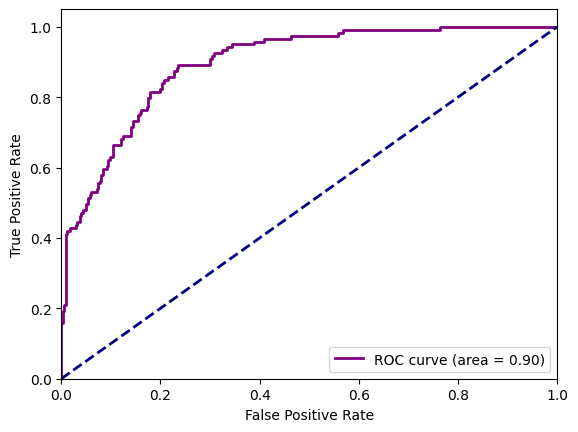

In [100]:
plt.plot(fpr, tpr, color='purple', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

ROC-кривая показывает соотношение true positive rate и false positive rate (доли верно классифицированных положительных примеров и неверно классифицированных положительных примеров) при различных порогах отсечения. По виду получившейся кривой можно отметить, что она расположена довольно близко к левому верхнему краю, удалена от пунктирной линии, что говорит о довольно высоких предсказывающих свойствах модели. Оцениваемая модель по умолчанию предполагает порог отсечение 0,5.

Чтобы оценить качество полученной модели, обращаем внимание на значение AUC (площади под кривой), которое составляет 0,9. Значение очень близко к 1, что говорит о том, что модель очень хорошо различает классы.

##Задание 3

3. Оцените статистическую значимость регрессионных коэффициентов. Подробно интерпретируйте особенности взаимосвязи между каждым из предикторов и зависимой переменной.

In [101]:
#выведу коэффициенты регрессии
coefs = pd.DataFrame()
coefs['Coefs'] = model1.params[1:]
coefs['Features'] = model1.params.index[1:]
coefs.set_index('Features', inplace=True)
print('Intercept = ', model1.params[0])
coefs

Intercept =  -4.400453354251009


,Coefs
Features,
loc,0.110665
cope,0.141427
teaching,-0.111659
research,0.019564
pastoral,0.046632
gender_male,-0.230101
degree_mba,-0.137884
degree_ms,-0.041644


In [102]:
#выведу коэффициенты и отношение шансов для каждой переменной
coefs['OddsRatio'] = np.exp(coefs.Coefs)
coefs

,Coefs,OddsRatio
Features,,
loc,0.110665,1.117021
cope,0.141427,1.151916
teaching,-0.111659,0.894349
research,0.019564,1.019757
pastoral,0.046632,1.047737
gender_male,-0.230101,0.794453
degree_mba,-0.137884,0.871199
degree_ms,-0.041644,0.959212


In [103]:
def yes_no(p_value, level = 0.05):
    if abs(p_value) < level:
        return 'significant'
    else:
        return 'non-significant'

In [104]:
#проверим через алгоритм полученные коэффициенты на значимость
pvals = pd.DataFrame()
pvals['p_values'] = model1.pvalues[1:]
pvals['5% level']= pvals['p_values'].apply(yes_no)
pvals['p_values'] = pvals['p_values'].map('{:.3f}'.format)
pvals['Features'] = model1.params.index[1:]
pvals.set_index('Features',inplace=True)
pvals

,p_values,5% level
Features,,
loc,0.000,significant
cope,0.000,significant
teaching,0.000,significant
research,0.061,non-significant
pastoral,0.000,significant
gender_male,0.433,non-significant
degree_mba,0.732,non-significant
degree_ms,0.912,non-significant


Статистически не значимы коэффициенты при переменных research, gender_male, degree_mba, degree_ms. Значения p-value для коэффициентов при этих переменных выше уровня значимости 5%.

In [105]:
f'Статистически не значимые предикторы: {model1.pvalues[model1.pvalues > 0.05].index.values}'

"Статистически не значимые предикторы: ['research' 'gender_male' 'degree_mba' 'degree_ms']"

In [106]:
f'Статистически значимые предикторы: {model1.pvalues[model1.pvalues < 0.05].index.values}'

"Статистически значимые предикторы: ['const' 'loc' 'cope' 'teaching' 'pastoral']"

Для интерпретации взаимосвязей между переменными используем отношения шансов (Odds Ratios) при переменных, которые рассчитаны как экспонента от коэффициентов регрессии.

- Экспонента от коэффициента регрессии при переменной loc больше 1, поэтому можно сделать вывод о положительной взаимосвязи между loc и burnout. Увеличение показателя loc на 1 балл (уменьшением ощущения контроля над ситуацией) повышает шансы испытать выгорание в 1,12 раза.

- Экспонента от коэффициента регрессии при переменной cope больше 1, поэтому можно сделать вывод о положительной взаимосвязи между loc и burnout. Увеличение показателя cope на 1 балл (снижение способности справляться со сложностями) повышает шансы столкнуться с проблемой выгорания в 1,15 раз.

- Экспонента от коэффициента регрессии при переменной cope меньше 1, значит взаимосвязь между переменными teaching и burnout отрицательная.
Увеличение стресса от преподавания на 1 балл снижает шансы выгореть от трудовой деятельности на 11% ((1-0,89)*100%).

- Отношение шансов больше 1, значит взаимосвязь переменных pastoral и burnout положительная. Повышение стресса от оказания безвозмездной помощи увеличивает шансы испытать выгорание в 1,05 раз.

- Стресс от проведения исследований статистически значимо не связан с шансам столкнуться с выгоранием на работе.

- Шансы пострадать от переутомления у мужчин статистически значимо не отличаются от шансов женщин.

- Шансы респондента с ученой степенью мастера делового администрирования столкнуться с выгоранием статистически значимо не отличаются от шансов кандидата наук.

- Шансы пострадать от выгорания у магистров статистически значимо не отличаются от шансов кандидата наук.

##Задание 4

4. Проведите диагностику модели (проверьте остатки на нормальность, выявите выбросы, оцените мультиколлинартность). Проведите кросс-валидацию модели и опишите полученные результаты.

In [107]:
p = stats.kstest(model1.resid_generalized, 'norm', args=(model1.resid_generalized.mean(), model1.resid_generalized.std())).pvalue
print('P-value: {:.3f}'.format(p))

P-value: 0.000


<Axes: ylabel='Density'>

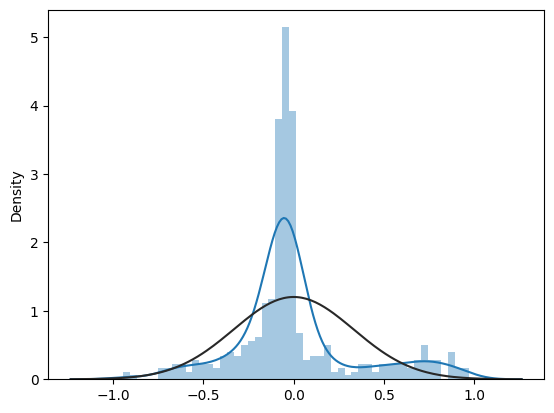

In [108]:
sns.distplot(model1.resid_generalized, fit=stats.norm)

По виду гистограммы можно определить, что распределение остатков статистически значимо отличается от нормального. Распределение отличается большей пиковостью и ассиметрией по сравнению с нормальным распределением.

По результатам теста на нормальность нулевая гипотеза отвергается, так как p-value ниже 0,05. Распределение отстатков статистически значимо отличается от нормального.



###Мультиколлинеарность

In [109]:
vifs = np.array([vif(model1.model.exog, i) for i in range(model1.model.exog.shape[1])])

In [110]:
vif_df = pd.DataFrame()
vif_df['VIF'] = vifs[1:]
vif_df['Features'] = model1.params.index[1:]
vif_df.sort_values(by=['VIF'])

,VIF,Features
5,1.037647,gender_male
6,1.063155,degree_mba
3,1.094108,research
7,1.110020,degree_ms
0,1.266576,loc
4,1.397120,pastoral
1,1.790338,cope
2,2.294505,teaching


Коэффициент вздутия дисперсии VIF показывает силу корреляции каждого предиктора с другими независимыми переменными. Все значения VIF ниже 10, значит отсутствует проблема мультиколлинеарности.

###Выбросы и влияющие наблюдения

In [111]:
influence = model1.get_influence()
inf_sum = influence.summary_frame()
inf_sum

,dfb_const,dfb_loc,dfb_cope,dfb_teaching,dfb_research,dfb_pastoral,dfb_gender_male,dfb_degree_mba,dfb_degree_ms,cooks_d,standard_resid,hat_diag,dffits_internal
0,-0.000077,0.000090,0.000091,-0.000063,0.000060,0.000062,0.000011,0.000032,-0.000001,1.763404e-09,0.010350,0.000148,0.000126
1,-0.171933,0.044890,-0.039504,0.086107,0.037037,0.090012,0.055133,0.132457,-0.012797,9.056613e-03,0.910448,0.089529,0.285499
2,-0.085469,-0.093647,-0.183203,0.145386,-0.005403,0.042401,0.132123,0.285560,-0.031243,2.017469e-02,3.444829,0.015070,0.426113
3,-0.037598,-0.117051,-0.091689,0.080195,-0.011634,0.027119,0.135682,0.286910,-0.033216,1.652768e-02,2.850026,0.017984,0.385680
4,-0.027676,0.048597,0.039177,-0.033907,0.027381,0.019728,0.026616,0.054002,-0.003349,8.287365e-04,0.454349,0.034871,0.086363
...,...,...,...,...,...,...,...,...,...,...,...,...,...
462,-0.008880,0.007033,0.005543,-0.004720,0.005839,0.007466,0.001977,0.001637,0.001572,1.494100e-05,-0.161256,0.005145,-0.011596
463,-0.024637,0.007811,0.003428,0.004856,0.009860,0.011541,0.005261,0.003749,0.004525,9.132021e-05,-0.267371,0.011366,-0.028668
464,-0.003870,-0.125325,0.011844,-0.064213,-0.041250,0.149197,0.054319,0.049851,0.010498,1.035830e-02,-1.127410,0.068333,-0.305327
465,-0.011941,0.008968,0.002976,-0.002667,-0.005150,0.017588,0.005159,0.002093,0.002065,7.628996e-05,-0.248364,0.011008,-0.026203


In [112]:
inf_sum['dffits_internal'][(inf_sum['dffits_internal']>1) | (inf_sum['dffits_internal']<-1)].sort_values()
#потенциальные влияющие наблюдения

,dffits_internal


Не выявлено потенциально влияющих наблюдений.

In [113]:
inf_sum['standard_resid'][(inf_sum['standard_resid']>3) | (inf_sum['standard_resid']<-3)].sort_values()
#потенциальные выбросы

,standard_resid
156,-4.169823
327,-3.455007
151,-3.126775
108,3.121519
30,3.230426
2,3.444829
73,3.884140
17,4.042509
62,5.823117


Вывели список выбросов. Попробую удалить выбросы и построить модель без них.

In [114]:
df_flt = df2.drop(df2[(inf_sum['standard_resid']>3) | (inf_sum['standard_resid']<-3)].index)
#датафрейм, очищенный от выбросов

In [115]:
df_flt.shape

(458, 14)

###Новая модель после удаления выбросов

In [116]:
df_model2 = df_flt.dropna(subset=['loc', 'cope', 'teaching', 'research', 'pastoral', 'gender_male',
              'degree_mba', 'degree_ms', 'burnout2'])
df_model2.shape

(458, 14)

In [117]:
x_mult = df_model2[['loc', 'cope', 'teaching', 'research', 'pastoral', 'gender_male',
              'degree_mba', 'degree_ms']]
y = df_model2['burnout2']
x_mult_constant = sm.add_constant(x_mult)

In [118]:
model2 = sm.Logit(y, x_mult_constant).fit()
print(model2.summary())

Optimization terminated successfully.
         Current function value: 0.291127
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:               burnout2   No. Observations:                  458
Model:                          Logit   Df Residuals:                      449
Method:                           MLE   Df Model:                            8
Date:                Thu, 17 Apr 2025   Pseudo R-squ.:                  0.4789
Time:                        17:05:14   Log-Likelihood:                -133.34
converged:                       True   LL-Null:                       -255.89
Covariance Type:            nonrobust   LLR p-value:                 1.878e-48
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -5.3422      1.238     -4.314      0.000      -7.770      -2.915
loc             0.1367    

In [119]:
print('R^2 = {:f}'.format(model2.prsquared))
print('Model significance = {:f}'.format(model2.llr_pvalue))

R^2 = 0.478928
Model significance = 0.000000


После удаления выбросов повысилось значение Rˆ2. Теперь модель объясняет 47,9% дисперсии зависимой переменной. В прошлой модели Rˆ2 составил 39,6%.

F-test significance < 0.05, модель по-прежнему остается статистически значимой.

###Матрица ошибок после удаления выбросов

In [120]:
cm = model2.pred_table()
cm

array([[318.,  27.],
       [ 41.,  72.]])

In [121]:
print('TN: {} | FP: {}\n-------------------\nFN: {}  | TP: {}'.format(cm[0,0], cm[0,1], cm[1,0], cm[1,1]))

TN: 318.0 | FP: 27.0
-------------------
FN: 41.0  | TP: 72.0


In [122]:
accuracy = (cm[0,0] + cm[1,1]) / sum(sum(cm))
print('Точность (процент верно предсказанных событий): = {}'.format(accuracy))

Точность (процент верно предсказанных событий): = 0.851528384279476


После удаления выбросов повысилась точность предсказания результатов (85,1% по сравнению 83%).

In [123]:
precision = (cm[1,1] / (cm[1,1] + cm[0,1]))
print('Precision: = {}'.format(precision))

Precision: = 0.7272727272727273


In [124]:
recall = (cm[1,1] / (cm[1,1] + cm[1,0]))
print('Recall (sensitivity): = {}'.format(recall))

Recall (sensitivity): = 0.6371681415929203


In [125]:
f1_score = 2* (precision * recall / (precision + recall))
print('F1-score: = {}'.format(f1_score))

F1-score: = 0.679245283018868


Незначительно, но повысились метрики precision (72,7% vs 71,7%), recall (63,7% vs 55,5%)и f1 score (67,9% vs 62,6%). Значительнее всего увеличение recall

In [126]:
fpr, tpr, _ = roc_curve(df_model2.burnout2, model2.predict())
roc_auc = auc(fpr, tpr)

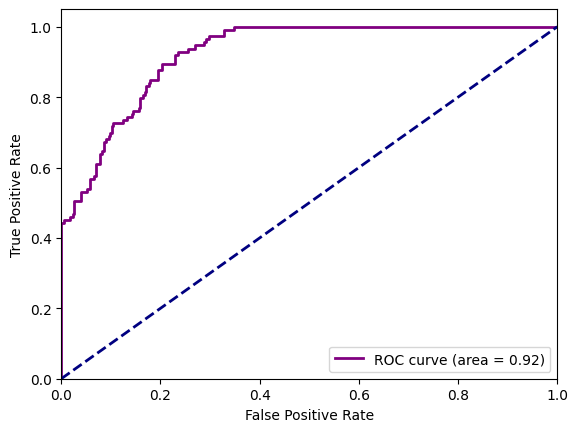

In [127]:
plt.plot(fpr, tpr, color='purple', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

ROC-кривая в этой модели ближе к левому верхнему углу, больше удалена от пунктирной диагональной линии. Значение площади под кривой (AUC) возросло по сравнению с предыдущей ситуацией. Качество модели после удаления выбросов повысилось, хоть и не очень значительно.

###Сохранение предсказанной вероятности наступления события для каждого наблюдения

In [128]:
df_model2['probability'] = model2.predict()
df_model2

,burnout,loc,cope,teaching,research,pastoral,gender,degree,burnout2,degree_mba,degree_ms,degree_phd,gender_female,gender_male,probability
0,Burnt Out,61.764706,81.679389,94.545455,81.250000,96.296296,male,mba,1,1,0,0,0,1,0.999992
1,Burnt Out,42.941176,39.694656,94.545455,60.416667,87.037037,male,mba,1,1,0,0,0,1,0.577756
3,Burnt Out,13.529412,25.190840,60.000000,62.500000,66.666667,male,mba,1,1,0,0,0,1,0.080605
4,Burnt Out,38.235294,34.351145,61.818182,68.750000,61.111111,male,mba,1,1,0,0,0,1,0.900594
5,Burnt Out,34.705882,22.900763,56.363636,54.166667,53.703704,male,mba,1,1,0,0,0,1,0.397340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
462,Not Burnt Out,7.647059,17.557252,45.454545,47.916667,33.333333,female,phd,0,0,0,1,1,0,0.011718
463,Not Burnt Out,6.470588,10.687023,27.272727,56.250000,31.481481,female,phd,0,0,0,1,1,0,0.044499
464,Not Burnt Out,55.882353,24.427481,69.090909,64.583333,29.629630,female,phd,0,0,0,1,1,0,0.553978
465,Not Burnt Out,7.647059,13.740458,34.545455,79.166667,24.074074,female,phd,0,0,0,1,1,0,0.039485


###Кросс-валидация

Выборку разделили на обучающую и тестовую на 80% и 20% соответственно.

In [129]:
X_train, X_test, y_train, y_test = train_test_split(x_mult, y, test_size=0.2, random_state=42)

In [130]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_train)
clf_report = pd.DataFrame(classification_report(y_train, pred, output_dict=True))
print("Train Result:\n================================================")
print(f"Accuracy Score: {accuracy_score(y_train, pred) * 100:.2f}%")
print("_______________________________________________")
print(f"CLASSIFICATION REPORT:\n{clf_report}")
print("_______________________________________________")
print(f"Confusion Matrix: \n {confusion_matrix(y_train, pred)}\n")

Train Result:
Accuracy Score: 84.43%
_______________________________________________
CLASSIFICATION REPORT:
                    0          1  accuracy   macro avg  weighted avg
precision    0.880952   0.694444  0.844262    0.787698      0.837638
recall       0.921708   0.588235  0.844262    0.754972      0.844262
f1-score     0.900870   0.636943  0.844262    0.768906      0.839575
support    281.000000  85.000000  0.844262  366.000000    366.000000
_______________________________________________
Confusion Matrix: 
 [[259  22]
 [ 35  50]]



In [131]:
pred = lr.predict(X_test)
clf_report = pd.DataFrame(classification_report(y_test, pred, output_dict=True))

print("Test Result:\n================================================")
print(f"Accuracy Score: {accuracy_score(y_test, pred) * 100:.2f}%")
print("_______________________________________________")
print(f"CLASSIFICATION REPORT:\n{clf_report}")
print("_______________________________________________")
print(f"Confusion Matrix: \n {confusion_matrix(y_test, pred)}\n")

Test Result:
Accuracy Score: 89.13%
_______________________________________________
CLASSIFICATION REPORT:
                   0          1  accuracy  macro avg  weighted avg
precision   0.909091   0.846154  0.891304   0.877622      0.889936
recall      0.937500   0.785714  0.891304   0.861607      0.891304
f1-score    0.923077   0.814815  0.891304   0.868946      0.890128
support    64.000000  28.000000  0.891304  92.000000     92.000000
_______________________________________________
Confusion Matrix: 
 [[60  4]
 [ 6 22]]



Метод кросс-валидации позволяет оценить, как работает модель на независимых данных, что она не переобучена на исходных данных. Поэтому датасет был разделен на обучающую и тестовую выборки, чтобы обучить модель на обучающей выборке и проверить ее на тестовой. Точность предсказаний на тестовой выборке составляет 81,9%. Значение ниже полученного при исходной модели после удаления выбросов (85%), тем не менее все равно говорит о высоком качестве предсказаний.

Если проверить модель на 80% выборке, то точность тоже будет высокой и составит 83,11%, что даже немного превышает точность модели, построенной на полном наборе данных.

##Задание 5

5. Сформулируйте общие содержательные выводы по результатам регрессионного анализа данных (общие содержательные выводы - это не копирование того, что вы писали в предыдущих пунктах). Какие результаты анализа данных для вас оказались очевидными, а какие неожиданными?

В результате проведения регрессионного анализа были проверены следующие гипотезы:

1. Между полом и выгоранием на работе нет взаимосвязи - **гипотеза подтвердилась**

2. Выгорание может наступить у работника вне зависимости от его ученой степени. - **гипотеза подтвердилась**

3. С ростом ощущения своего контроля над ситуацией снижается вероятность выгорания на работе (то есть предполагается прямая взаимосвязь между loc и burnout). - **гипотеза подтвердилась**

4. Чем выше способность справлять со сложностями, тем ниже шансы выгореть на работе (прямая взаимосвязь между cope и burnout). - **гипотеза подтвердилась**

5. Есть прямая взаимосвязь между испытываемым стрессом от преподавания (teaching) и фактом выгорания. - **гипотеза не подтвердилась**


6. Есть прямая взаимосвязь между стрессом от проведения исследований (research) и выгоранием. - **гипотеза не подтвердилась**

7. Выгорание напрямую связана со стрессом от бескорыстной помощи коллегам и студентам (pastoral). - **гипотеза подтвердилась**

Большая часть предположений на счет взаимосвязи между предикторами и выгоранием подтвердилась. Было ожидаемо, что с выгоранием могут столкнуться в равной степени как мужчины, так и женщины, так как выгорание больше зависит от характера работы, от атмосферы, от ряда субъективных факторов, но не от пола. Кроме того, можно было предугадать и отсутствие взаимосвязи между ученой степенью и выгоранием. Логично было предположить, что когда человек ощущает контроль над ситуацией и чувствует свою способность справиться с проблемами, он не впадает в панику, чувствует себя более уверенным в своих профессиональных качествах, может получать удовольствие от работы и не выгореть от трудовой деятельности. Также логично было предположить, что от стресса от бескорыстной помощи работник был более склонен к выгоранию, особенно если не получал отдачи.

Удивило в полученных результатах то, что не было обнаружено взаимосвязи между стрессом от проведения исследований и выгоранием, а также отрицательная связь между стрессом от преподавания и выгоранием.

Удивительным результатом было также то, что при кросс-валидации и проверке модели на более сокращенной выборке результаты accuracy получились не ниже, чем при исходной выборке, а результаты по другим метрикам были выше.


Комментарии к заданию и принципам его оценивания:

 - Все пункты задания должны сопровождаться выполненным фрагментом кода. В этом задании будет проверяться корректность работы кода, то есть будут последовательно запущены ячейки, чтобы убедиться, что код не выдаст ошибку в какой-то момент. Перед отправкой работы на проверку рекомендуется "прогнать" код.
 - Если Вы получили результаты в виде статистических показателей, таблиц или графиков, при этом никак их не прокомментировали и не сформулировали содержательные выводы на их основе, то работа оценивается в 0 баллов, в этом случае анализ данных не проведён.
 - Если Вы полностью выполнили это задание, то получаете за него 8 баллов (отлично). Для получения более высокой оценки нужно выйти за рамки предложенного задания. В случае с текущим заданием это может быть дополнительное самостоятельное изучение инструментов регрессионного анализа и их применение, или развернутое и глубокое исследование имеющихся данных на основе использования пройденных на занятиях методов.
 - В этом задании 5 пунктов. Первый весит 15%, второй - 20%, третий - 30%, четвертый - 20%, пятый - 15%.
 - Задание можно выполнять на русском или на английском языке, критерии оценивания при этом не меняются;
 - Задание можно выполнять индивидуально или в группе из 2 человек, критерии оценивания при этом не меняются;
 - В названии загружаемого в Smart LMS файла нужно указать фамилию(ии) автора(ов) работы.

### Этот файл нужно сохранить как Jupyter Notebook (.ipynb) и загрузить в Smart LMS до 13:00 18 апреля. Не рекомендую загружать файл в Smart LMS в последние несколько минут перед дедлайном. После дедлайна выполненные задания не принимаются.